In [39]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Q1)	Load the data. Please download the Boston Dataset from Blackboard and read it in Pyhton.**

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Load the dataset
BostonData = pd.read_csv('/content/drive/MyDrive/BostonDataset_LinearRegression/Boston.csv', index_col=0)

# Display the first 4 rows
BostonData.head(4)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4


**Q1) How many variables in the dataset?  What are they? Are they quantitative or qualitative variables?**


In [5]:
print(f'Nnumber of columns(variables): {len(BostonData.columns)}') # check the number o
print(f'Nnumber of rows (samples): {len(BostonData)}') # check the number of rows (samp
print('Variables in the dataset:', list(BostonData.columns)) # List the variables in th

Nnumber of columns(variables): 14
Nnumber of rows (samples): 506
Variables in the dataset: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat', 'medv']


**1. How many variables?** There are 14 variables (columns).

**2. What are they?** The variables are: crim, zn, indus, chas, nox, rm, age, dis, rad, tax, ptratio, black, lstat, and medv.

**3. Quantitative vs. Qualitative?**

- **Qualitative (Categorical):** chas (Charles River dummy variable) and rad (index of accessibility to radial highways).

- **Quantitative (Numerical):** All other variables (crim, zn, indus, nox, rm, age, dis, tax, ptratio, black, lstat, medv) are quantitative as they represent continuous or discrete numerical measurements.

**Q2) .	Data visualization. Please use the scatterplots and correlation plot to visualize this dataset.**



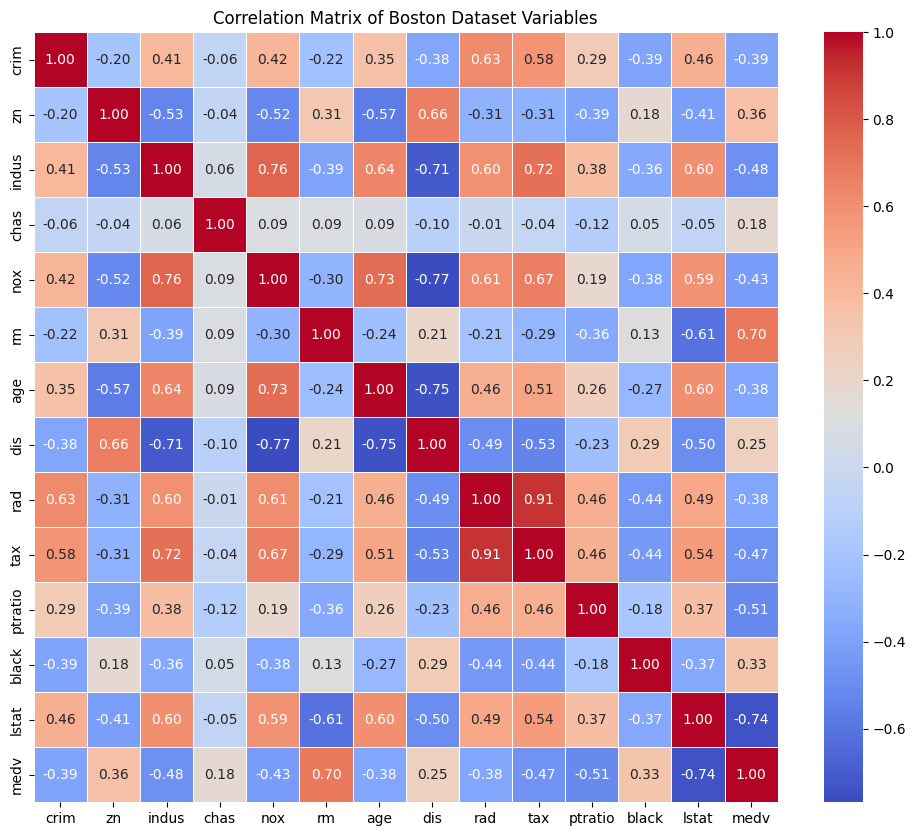

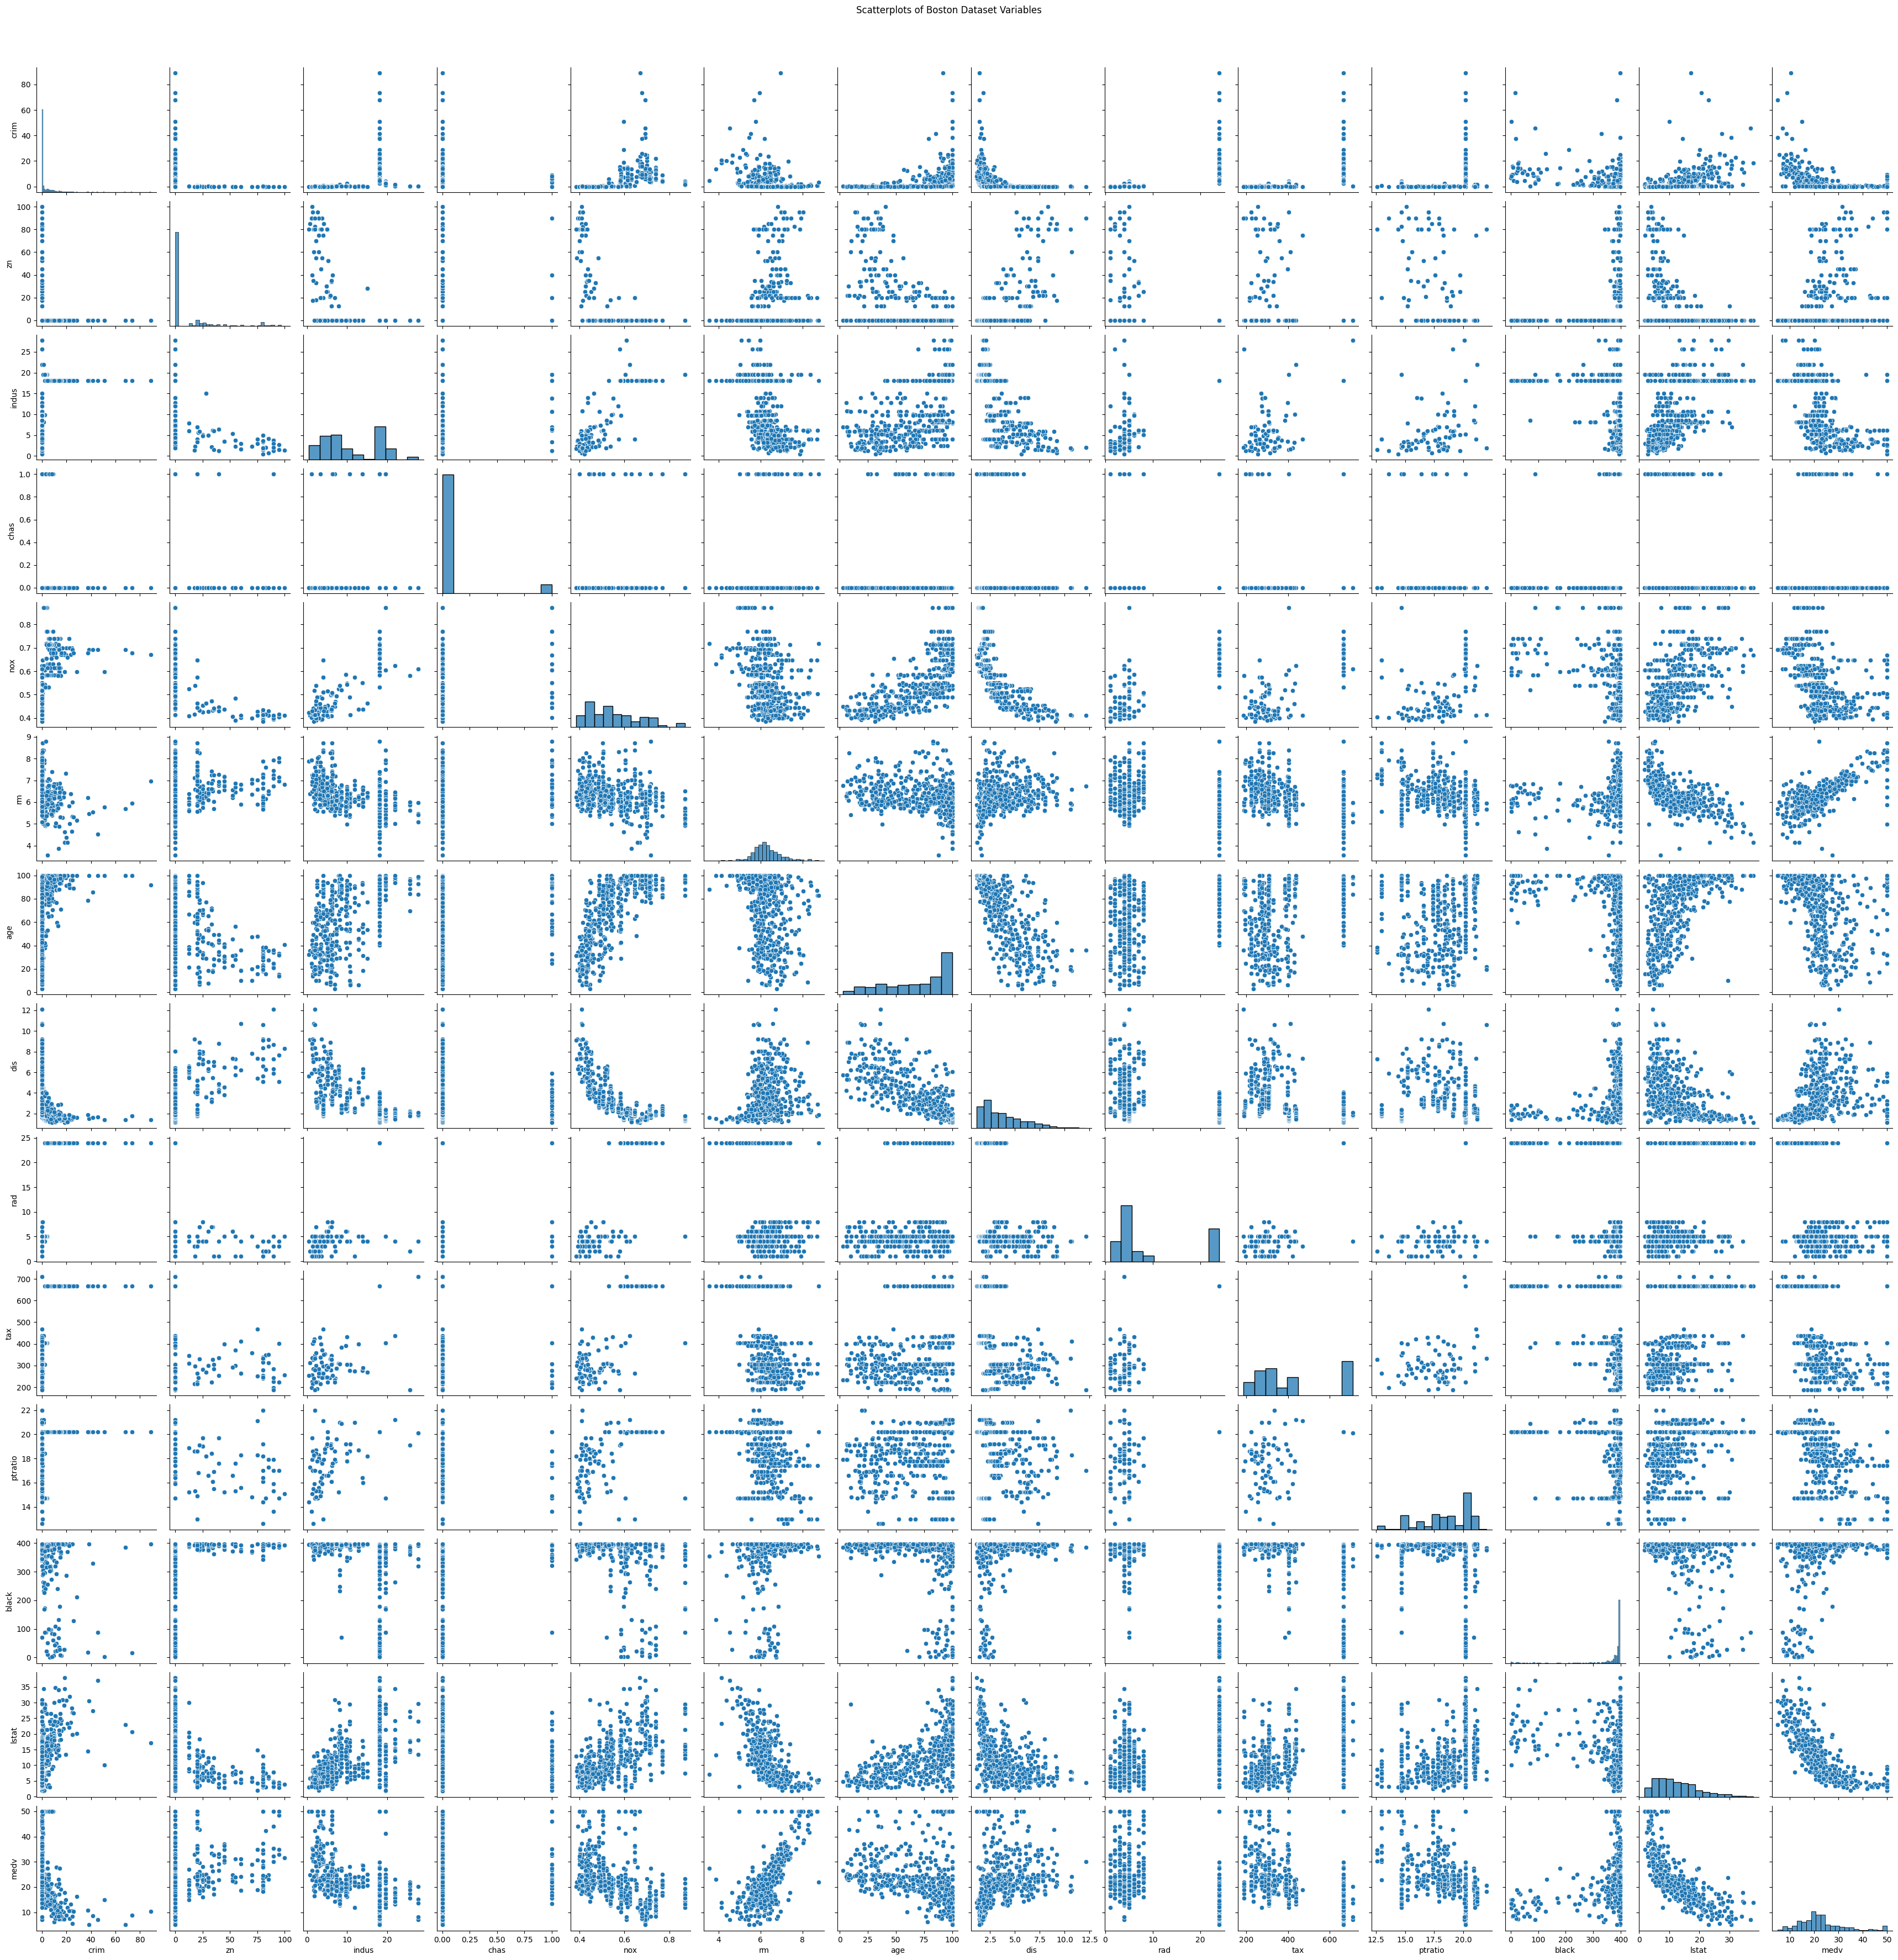

In [6]:


# 1. Correlation Plot (Heatmap)
plt.figure(figsize=(12, 10))
correlation_matrix = BostonData.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Boston Dataset Variables')
plt.show()

# 2. Scatterplots for some key relationships
sns.pairplot(BostonData)
plt.suptitle('Scatterplots of Boston Dataset Variables', y=1.02)
#plt.title('Scatterplots of Boston Dataset Variables')

plt.show()


**Q2: What you observe?**?

**Correlation Analysis**

•	rm has a strong positive correlation with medv (~0.7): more rooms → higher house prices.

•	lstat has a strong negative correlation with medv (~−0.74): higher lower status population → lower house prices.

•	ptratio is moderately negatively correlated with medv (~−0.5): larger class sizes → cheaper houses.

•	nox and indus are negatively correlated with medv: more pollution and industrial land → lower house prices.

•	rad and tax are very strongly positively correlated (>0.9): better highway access areas tend to have similar, higher tax rates.

•	indus is positively correlated with nox, rad, and tax: industrial areas are more polluted, closer to highways, and taxed more.

•	dis is strongly negatively correlated with nox, indus, and rad: locations farther from job centers are less industrial, less polluted, and have lower highway access.

•	Strong correlations among predictors (e.g., rad–tax, indus–nox) indicate multicollinearity, which can affect regression coefficient interpretation.

**ScatterPlot Analysis**

•	When rm (rooms) increases, medv (house price) usually increases.

•	When lstat (lower status %) increases, house prices usually decrease.

•	More nox (pollution) and more indus (industrial land) are linked with lower house prices.

•	Higher ptratio (more students per teacher) tends to go with lower house prices, but the pattern is weaker.

• Variables like rad and tax appear in vertical stripes, meaning they only take a few fixed values




## **3. Fit Simple Regression Model**

**Q3. Simple linear regression. Please fit a simple linear regression model between medv (median house value) and lstat (percent of households with low socioeconomic status)**


In [7]:
# Define predictor and target
X = BostonData["lstat"]          # independent variable
y = BostonData["medv"]           # dependent variable

# Add intercept term
X = sm.add_constant(X)

# Fit OLS (ordinary least squares) model
model = sm.OLS(y, X).fit()

# Print summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Fri, 20 Feb 2026   Prob (F-statistic):           5.08e-88
Time:                        03:42:26   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         34.5538      0.563     61.415      0.0

Based on the OLS regression results:
- **Coefficient for 'lstat'**: -0.9500 (indicating that for every 1 unit increase in 'lstat', 'medv' decreases by approximately 0.95 units).
- **P-value for 'lstat'**: 0.000 (which is less than 0.05, indicating a statistically significant relationship).
- **R-squared value**: 0.544 (meaning the model explains approximately 54.4% of the variance in the median house value).
- **Equation**: The fitted model is: (medv) ̂=34.55-0.95×lstat.
- **Intercept**: (34.55) means: when lstat = 0, the predicted median house price is about $34,550.

- **Slope** (−0.95) means: for each 1 unit increase in lstat, the predicted median house price decreases by about $950.


**Q3 a) Is there a relationship between median house value and percent of households
with low socioeconomic status?**

Ans.
Yes, there is a strong negative relationship between median house value (medv) and the percent of households with low socioeconomic status (lstat).

1. **P-value**: The p-value for the lstat coefficient is 0.000, which is far below the common significance level of 0.05. This allows us to reject the null hypothesis that there is no relationship.
2. **Direction**: The relationship is negative (coefficient = -0.9500), meaning that as the percentage of lower status population increases, the median home value tends to decrease.
3. **Strength:** The R-squared of 0.544 indicates that approximately 54.4% of the variability in house values can be explained by this single variable.

**Q3 b) How large is the effect of percent of households with low socioeconomic status on
median house value?**

Ans. The effect is fairly large in this simple linear model.

•	The slope for lstat is about −0.95.

•	This means: for every 1 point increase in lstat (1 percentage point more low status households), the predicted median house value drops by about $950.

•	A 10 point increase in lstat would therefore be associated with roughly a $9,500 decrease in median house value

**Q3 c) How good this model fits the data?**

Ans. The model fits the data moderately well but not perfectly.

- R^2≈0.544: about 54.4% of the variation in median house value is explained by lstat alone, so there is still about 45.6% unexplained.

- The overall model is highly significant (very large F statistic with p value ≈ 0), so it clearly captures an important relationship, but other variables are needed for a more accurate fit.


**Q3 d) Visualize the fitted line**

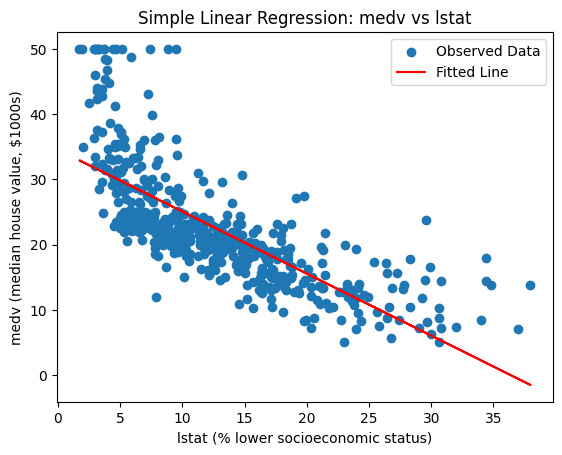

In [8]:
plt.scatter(X['lstat'], y, label='Observed Data') # Plot the observed data points
predicted_values = model.predict(X) # Calculate the predicted values
plt.plot(X['lstat'], predicted_values, color='red', label='Fitted Line') # Plot the reg
plt.xlabel('lstat (% lower socioeconomic status)') # Label the x-axes
plt.ylabel('medv (median house value, $1000s)') # Label the y-axes
plt.title("Simple Linear Regression: medv vs lstat")
plt.legend() # Add a legend
plt.show()


**Q3 e) If the percent of households with low socioeconomic status for three new neighborhoods are 5, 10 and 15, what will be the predictions of their median house value?**


In [9]:
# New lstat values
new_lstat = pd.DataFrame({"lstat": [5, 10, 15]})
new_lstat_const = sm.add_constant(new_lstat)

# Predict median house values
predictions = model.predict(new_lstat_const)

print("New lstat values:", new_lstat["lstat"].tolist())
print("Predicted medv values:", predictions.tolist())

New lstat values: [5, 10, 15]
Predicted medv values: [29.80359411059312, 25.05334734180316, 20.303100573013197]



**Q3 f) What are the 95% confidence intervals of your predictions?**

In [10]:
# New lstat values
new_lstat = pd.DataFrame({"lstat": [5, 10, 15]})
new_lstat_const = sm.add_constant(new_lstat)

# Predictions with 95% confidence intervals for the mean
pred_frame = model.get_prediction(new_lstat_const).summary_frame(alpha=0.05)

print(pred_frame[["mean", "mean_ci_lower", "mean_ci_upper"]])

        mean  mean_ci_lower  mean_ci_upper
0  29.803594      29.007412      30.599776
1  25.053347      24.474132      25.632563
2  20.303101      19.731588      20.874613


**Q3 g) If the true median house values for three new neighborhoods are 33, 20, 50 respectively, what are the prediction errors?**

In [11]:
# New lstat values and true medv values
new_lstat = pd.DataFrame({"lstat": [5, 10, 15]})
true_medv = pd.Series([33, 20, 50], name="true_medv")

# Predictions
new_lstat_const = sm.add_constant(new_lstat)
predictions = model.predict(new_lstat_const)

# Prediction errors (true - predicted)
errors = true_medv - predictions
result = pd.DataFrame({
    "lstat": new_lstat["lstat"],
    "true_medv": true_medv,
    "predicted_medv": predictions,
    "error": errors
})

print(result)

   lstat  true_medv  predicted_medv      error
0      5         33       29.803594   3.196406
1     10         20       25.053347  -5.053347
2     15         50       20.303101  29.696899


 **Q3 g) Which prediction is more accurate?**

 The first prediction (for lstat = 5, true medv = 33) is the most accurate because it has the smallest absolute error (about 3.19).

**Q4. Residual plot. Please plot the residual plots of simple linear regression model fitted in Problem 3 and answer the following question.**

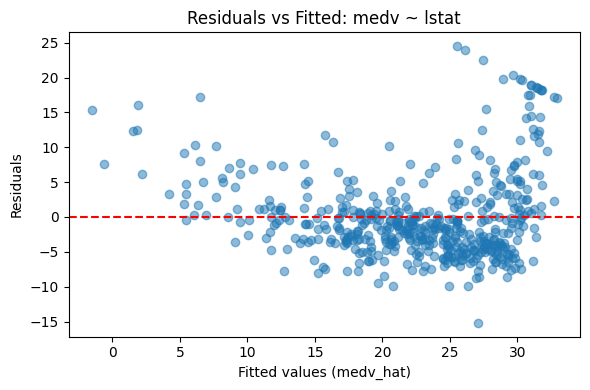

In [12]:


# Fitted values and residuals
fitted = model.fittedvalues      # ŷ
resid = model.resid              # y - ŷ

plt.figure(figsize=(6, 4))
plt.scatter(fitted, resid, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values (medv_hat)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted: medv ~ lstat")
plt.tight_layout()
plt.show()


**Q4 a) Is there a nonlinear relationship between medv and lstat?**

Yes, there is evidence of a nonlinear relationship between medv and lstat.
In the residuals vs fitted plot for the simple linear model medv ~ lstat, the residuals form a curved pattern (mostly positive at low and high fitted values, negative in the middle) instead of a random cloud around zero. This systematic curve indicates that a straight line does not fully capture the relationship, so a nonlinear model (for example adding lstat^2) would likely fit better.

**Q4 b) Is there correlation between error terms?**

In the residuals vs index plot, the residuals do not form a clear trend over the observation order; they bounce up and down around zero without a strong systematic pattern.


**Q4c) Is there heteroscedasticity between error terms?**

Yes, there is evidence of heteroscedasticity.
In the scale–location plot (sqrt of absolute residuals vs fitted values), the spread of points increases as the fitted median house value gets larger, forming a fan shaped pattern instead of a horizontal band. This indicates that the variance of the errors is not constant across all levels of medv, which is exactly what heteroscedasticity means.


**Q4d) Are there outliers?**

In [15]:
# IQR method on residuals
Q1 = resid.quantile(0.25)
Q3 = resid.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Boolean mask for outliers
outlier_mask = (resid < lower_bound) | (resid > upper_bound)

# Outlier rows with their residuals
outliers = BostonData.loc[outlier_mask].copy()
outliers["residual"] = resid[outlier_mask]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", outliers.shape[0])
print(outliers[["lstat", "medv", "residual"]])

Q1: -3.989611889553883
Q3: 2.033701013271788
IQR: 6.023312902825671
Lower bound: -13.024581243792388
Upper bound: 11.068670367510293
Number of outliers: 37
     lstat  medv   residual
99    3.57  43.8  12.637835
142  34.41  14.4  12.537357
158   4.59  41.3  11.106886
162   1.73  50.0  17.089745
163   1.92  50.0  17.270254
164   3.32  50.0  18.600323
167   3.70  50.0  18.961342
181   7.56  39.8  12.428532
187   4.45  50.0  19.673879
196   2.97  50.0  18.267806
204   3.81  48.5  17.565847
205   2.88  50.0  18.182301
215  29.55  23.7  17.220118
225   4.14  44.8  14.179363
226   4.63  50.0  19.844888
229   3.92  46.7  15.870353
234   3.95  48.3  17.498854
254   3.54  42.8  11.609334
257   3.11  44.0  12.400813
258   5.12  50.0  20.310412
262   7.26  43.1  15.443517
263   5.91  48.8  19.860951
268   7.44  50.0  22.514526
269   3.16  43.5  11.948315
281   3.76  45.4  14.418345
283   3.01  46.0  14.305808
284   3.16  50.0  18.448315
369   3.26  50.0  18.543320
370   3.73  50.0  18.989843
371 

**Observation**

Yes, there are outliers: 37 data points have unusually large positive or negative residuals according to the IQR criterion.

**Q5) Multiple linear regression. Please fit a multiple linear regression model between medv and the other variables.**

In [16]:
# Define predictors X and target y
X = BostonData.drop(columns=["medv"])   # all columns except medv
y = BostonData["medv"]                  # target

# Add intercept term
X_const = sm.add_constant(X)

# Fit multiple linear regression model
model = sm.OLS(y, X_const).fit()

# View full summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     108.1
Date:                Fri, 20 Feb 2026   Prob (F-statistic):          6.72e-135
Time:                        04:02:12   Log-Likelihood:                -1498.8
No. Observations:                 506   AIC:                             3026.
Df Residuals:                     492   BIC:                             3085.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.4595      5.103      7.144      0.0

**Q5 a) Is there a relationship between median house value and the other variables?**

Yes.
The overall F‑statistic for the multiple regression is very large (≈ 100.6) with a p‑value ≈ 3.4e‑134, so at least some predictors are jointly related to median house value

**Q5 b) Which variables are significant and how large are the effect?**

Based on the OLS Regression Results, we identify significant variables by looking for p-values (P>|t|) less than 0.05.

**Significant Variables (p < 0.05):**

- **nox (-17.7666):** The largest negative effect. A 1-unit increase in nitrogen oxides concentration is associated with a ~$17,766 decrease in median home value.

-  **rm (3.8099):** The largest positive effect. Each additional room adds roughly $3,810 to the value.

-	**chas (2.6867):** Houses near the Charles River are predicted to be ~$2,687 more expensive.

- **dis (-1.4756):** Each unit increase in distance to employment centers decreases value by ~$1,476.

-	**ptratio (-0.9527):** Higher student-teacher ratios (larger classes) decrease home values by ~$953 per unit.

- **lstat (-0.5248):** For every 1% increase in lower-status population, home values drop by ~$525.

- **Others:** crim, zn, rad, tax, and black are also statistically significant but have smaller absolute coefficients.

**Non-Significant Variables (p > 0.05):**

- indus (p=0.738) and age (p=0.958) do not have a statistically significant relationship with home value in this specific multiple regression model.


**Q5 c) How good this model fits the data?**

- R^2: the model explains about 74.1% of the variation in median house value.
- Adjusted R^2≈0.734, still high after penalizing for 14 predictors.

So the multiple linear regression provides a substantially better fit than the simple medv ~ lstat model (which had R^2≈0.544).

**Q5 d) Select the best subset of variables using forward selection, backward selection and mixed selection with AIC criteria.**


In [18]:


# Predictors and target
X_full = BostonData.drop(columns=["medv"])
# Drop index column if present
if "Unnamed: 0" in X_full.columns:
    X_full = X_full.drop(columns=["Unnamed: 0"])

y = BostonData["medv"]
all_cols = list(X_full.columns)

def fit_aic(feature_list):
    """Fit OLS on given features and return (AIC, model)."""
    X = sm.add_constant(X_full[feature_list])
    model = sm.OLS(y, X).fit()
    return model.aic, model

# ---------- FORWARD SELECTION ----------
forward_features = []
best_aic = float("inf")

while True:
    improved = False
    candidates = [c for c in all_cols if c not in forward_features]
    if not candidates:
        break

    aic_list = []
    for c in candidates:
        aic, _ = fit_aic(forward_features + [c])
        aic_list.append((aic, c))

    aic_new, best_new = min(aic_list, key=lambda x: x[0])
    if aic_new < best_aic - 1e-6:
        best_aic = aic_new
        forward_features.append(best_new)
        improved = True

    if not improved:
        break

print("Forward selection features:", forward_features)
print("Forward selection AIC:", best_aic)

# ---------- BACKWARD SELECTION ----------
backward_features = all_cols.copy()
X0 = sm.add_constant(X_full[backward_features])
model0 = sm.OLS(y, X0).fit()
current_aic = model0.aic

while True:
    if len(backward_features) == 1:
        break

    aic_list = []
    for c in backward_features:
        feats = [f for f in backward_features if f != c]
        aic, _ = fit_aic(feats)
        aic_list.append((aic, c))

    best_aic_drop, drop_var = min(aic_list, key=lambda x: x[0])
    if best_aic_drop < current_aic - 1e-6:
        backward_features.remove(drop_var)
        current_aic = best_aic_drop
    else:
        break

print("Backward selection features:", backward_features)
print("Backward selection AIC:", current_aic)

# ---------- MIXED (STEPWISE) SELECTION ----------
step_features = []
best_aic = float("inf")
changed = True

while changed:
    changed = False

    # Forward step
    candidates = [c for c in all_cols if c not in step_features]
    aic_forward = []
    for c in candidates:
        aic, _ = fit_aic(step_features + [c])
        aic_forward.append((aic, c))

    if aic_forward:
        aic_new, best_new = min(aic_forward, key=lambda x: x[0])
        if aic_new < best_aic - 1e-6:
            step_features.append(best_new)
            best_aic = aic_new
            changed = True

    # Backward step
    while step_features:
        aic_list = []
        for c in step_features:
            feats = [f for f in step_features if f != c]
            aic, _ = fit_aic(feats)
            aic_list.append((aic, c))

        best_back_aic, worst = min(aic_list, key=lambda x: x[0])
        if best_back_aic < best_aic - 1e-6:
            step_features.remove(worst)
            best_aic = best_back_aic
            changed = True
        else:
            break

print("Stepwise selection features:", step_features)
print("Stepwise selection AIC:", best_aic)


Forward selection features: ['lstat', 'rm', 'ptratio', 'dis', 'nox', 'chas', 'black', 'zn', 'crim', 'rad', 'tax']
Forward selection AIC: 3021.726387825062
Backward selection features: ['crim', 'zn', 'chas', 'nox', 'rm', 'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat']
Backward selection AIC: 3021.726387825062
Stepwise selection features: ['lstat', 'rm', 'ptratio', 'dis', 'nox', 'chas', 'black', 'zn', 'crim', 'rad', 'tax']
Stepwise selection AIC: 3021.726387825062


**Q5 e) Do different selection algorithms find the same subset? Which variables are selected?**


Yes, the different selection algorithms basically find the same subset.

•	**Forward selection and stepwise (mixed) selection** choose exactly the same 11 variables: lstat, rm, ptratio, dis, nox, chas, black, zn, crim, rad, tax.

•	**Backward selection** also ends with 11 variables and differs only in the order printed, not in which variables are kept: crim, zn, chas, nox, rm, dis, rad, tax, ptratio, black, lstat.

So all algorithms agree that these 11 predictors should be in the best AIC model, and they consistently drop indus and age (and the index column)


**Q5 f) Does variable selection improve the R-square? How about the adjusted R-square?**

In [20]:
# Predictors (drop target and index)
X_full = BostonData.drop(columns=["medv"])
if "Unnamed: 0" in X_full.columns:
    X_full = X_full.drop(columns=["Unnamed: 0"])
y = BostonData["medv"]

# 1) Full model with all predictors
Xc_full = sm.add_constant(X_full)
model_full = sm.OLS(y, Xc_full).fit()
print("Full model R^2:", model_full.rsquared)
print("Full model Adjusted R^2:", model_full.rsquared_adj)

# 2) Best-subset model from AIC selection
best_cols = ['lstat', 'rm', 'ptratio', 'dis', 'nox',
             'chas', 'black', 'zn', 'crim', 'rad', 'tax']

Xc_best = sm.add_constant(X_full[best_cols])
model_best = sm.OLS(y, Xc_best).fit()
print("Best-subset R^2:", model_best.rsquared)
print("Best-subset Adjusted R^2:", model_best.rsquared_adj)


Full model R^2: 0.7406426641094095
Full model Adjusted R^2: 0.733789726372463
Best-subset R^2: 0.7405822802569575
Best-subset Adjusted R^2: 0.7348057723274566


Using this code, I get:

- **Full model:** R^2≈0.7406, adjusted R^2≈0.7338.
- **Best subset model:** R^2≈0.7406 (almost identical), adjusted R^2≈0.7348.

Variable selection keeps the overall R^2 essentially the same (no real loss in explained variance) but slightly increases the adjusted R^2. This means the reduced 11 variable model explains the data about as well as the full model while being more efficient (fewer predictors), so its fit is marginally better after accounting for model complexity.


**Q6) Residual plot. Please plot the residual plots of multiple linear regression model fitted in Problem 5 and answer the following question.**

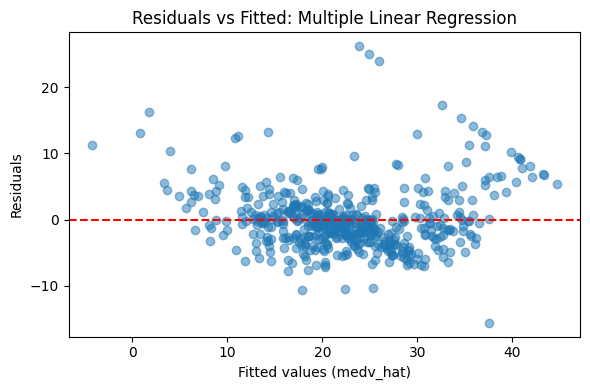

In [23]:
# Multiple linear regression: medv ~ all other variables
X = BostonData.drop(columns=["medv"])
if "Unnamed: 0" in X.columns:
    X = X.drop(columns=["Unnamed: 0"])
y = BostonData["medv"]

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()

# Fitted values and residuals
fitted = model.fittedvalues      # ŷ
multi_resid = model.resid              # y - ŷ

plt.figure(figsize=(6, 4))
plt.scatter(fitted, multi_resid, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values (medv_hat)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted: Multiple Linear Regression")
plt.tight_layout()
plt.show()


**Q6 a) Is there a nonlinear relationship?**

The residuals‑vs‑fitted plot looks more random than for the simple model, but there is still a slight bowl/curved shape and some structure around the center.
​
So the multiple linear model reduces nonlinearity but does not completely remove it; there is still some mild nonlinear pattern left.

**Q6 b) Is there correlation between error terms?**

In the residuals‑vs‑index plot, the residuals bounce up and down around zero without a clear upward/downward trend or long runs of only positive or only negative points.
This suggests there is no strong correlation (autocorrelation) between the error terms.


**Q6 c) Is there heteroscedasticity between error terms?**

The scale–location plot still shows the spread of residuals changing somewhat with fitted values (a bit wider in some fitted ranges than others), rather than a perfectly constant band.

So there is mild heteroscedasticity: the error variance is not completely constant, although it is less severe than in the simple linear model.

**Q6 d) Are there outliers?**

In [24]:
# IQR method on residuals
Q1 = multi_resid.quantile(0.25)
Q3 = multi_resid.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Boolean mask for outliers
outlier_mask = (resid < lower_bound) | (multi_resid > upper_bound)

# Outlier rows with their residuals
outliers = BostonData.loc[outlier_mask].copy()
outliers["residual"] = multi_resid[outlier_mask]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", outliers.shape[0])
print(outliers[["lstat", "medv", "residual"]])

Q1: -2.7297158760001716
Q3: 1.7770505682533315
IQR: 4.506766444253503
Lower bound: -9.489865542380425
Upper bound: 8.537200234633586
Number of outliers: 28
     lstat  medv   residual
65    8.05  33.0   9.626914
99    3.57  43.8   8.685454
142  34.41  14.4  10.411145
162   1.73  50.0  13.225330
163   1.92  50.0   9.442342
167   3.70  50.0  12.796525
187   4.45  50.0  14.115028
196   2.97  50.0   9.154443
215  29.55  23.7  12.580833
226   4.63  50.0  10.185381
229   3.92  46.7  11.243348
234   3.95  48.3  11.136714
254   3.54  42.8  12.854366
268   7.44  50.0   9.160443
365   5.29  21.9 -15.594474
366   7.12  27.5  13.218093
368  13.33  23.1  12.268377
369   3.26  50.0  26.199271
370   3.73  50.0  17.355926
371   2.96  50.0  15.393160
372   9.53  50.0  25.056687
373   8.88  50.0  24.000191
375  37.97  13.8  13.022202
376  13.44  15.0 -10.307131
402  20.32   7.2 -10.611745
413  34.37  17.9  16.181482
415  36.98   7.0  11.281311
506   7.88  11.9 -10.444212


**Q7) Use non-linear transformation to include lstat2.**


In [29]:


# Create nonlinear term lstat^2
X = BostonData[["lstat"]].copy()
X["lstat2"] = X["lstat"] ** 2    # squared term
y = BostonData["medv"]

# Add intercept
X_const = sm.add_constant(X)

# Fit quadratic regression: medv ~ lstat + lstat^2
quad_model = sm.OLS(y, X_const).fit()

print(quad_model.summary())


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.641
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     448.5
Date:                Fri, 20 Feb 2026   Prob (F-statistic):          1.56e-112
Time:                        04:36:10   Log-Likelihood:                -1581.3
No. Observations:                 506   AIC:                             3169.
Df Residuals:                     503   BIC:                             3181.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         42.8620      0.872     49.149      0.0

**Q7a) Is the model improved?**

Yes, the model is improved.

The simple linear model medv ~ lstat had R^2≈0.544.
The quadratic model medv ~ lstat + lstat^2 now has R^2≈0.641 and adjusted R^2≈0.639.

So the nonlinear model explains a larger share of the variance in medv, even after adjusting for the extra parameter.


**Q7 b) Is the nonlinear effect significant?**

Yes, the nonlinear effect is significant.

The coefficient for lstat2 is about 0.085 with a very large t‑value (≈ 11.6) and p‑value < 0.0001.

This means the squared term adds important information, so the curvature in the relationship between lstat and medv is statistically significant

**Q7 c) Use the residual plot to see if the nonlinear relationship is solved.**

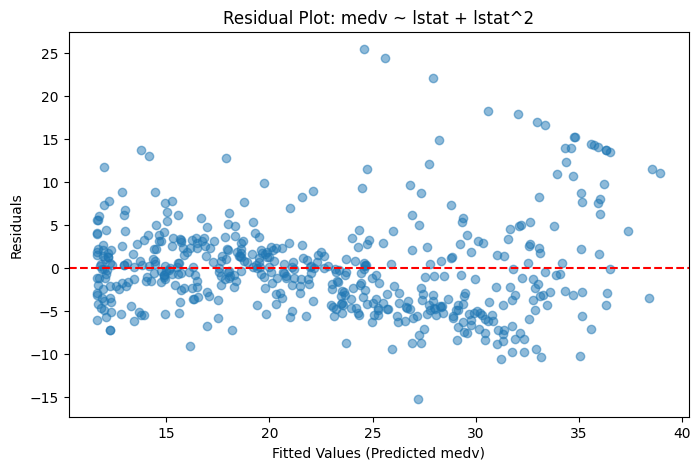

In [30]:
import matplotlib.pyplot as plt

# Get fitted values and residuals from the quadratic model
quad_fitted = quad_model.fittedvalues
quad_resid = quad_model.resid

plt.figure(figsize=(8, 5))
plt.scatter(quad_fitted, quad_resid, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values (Predicted medv)')
plt.ylabel('Residuals')
plt.title('Residual Plot: medv ~ lstat + lstat^2')
plt.show()

- In the simple linear model residual plot, the points formed a clear curve/bowl: residuals tended to be positive at low and high fitted values and negative in the middle.

- In your new quadratic plot (the one you just sent), the points are much more evenly scattered around the 0 line; there is no strong U shape any more, just some random spread.

- After adding the quadratic term lstat^2, the residuals vs fitted plot becomes more randomly scattered around zero, indicating that the main nonlinear relationship between medv and lstat has been adequately captured by the quadratic model.


**Q8 ) Include the interaction term lstat X black**

In [31]:
# Create interaction term lstat × black
X = BostonData[["lstat", "black"]].copy()
X["lstat_black"] = X["lstat"] * X["black"]   # interaction
y = BostonData["medv"]

# Add intercept
X_const = sm.add_constant(X)

# Fit model: medv ~ lstat + black + lstat:black
inter_model = sm.OLS(y, X_const).fit()

print(inter_model.summary())


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.561
Model:                            OLS   Adj. R-squared:                  0.559
Method:                 Least Squares   F-statistic:                     214.2
Date:                Fri, 20 Feb 2026   Prob (F-statistic):           1.96e-89
Time:                        04:50:22   Log-Likelihood:                -1631.7
No. Observations:                 506   AIC:                             3271.
Df Residuals:                     502   BIC:                             3288.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          18.3345      3.753      4.886      

**Q8 a ) Is the model improved?**

 Yes, but only a little.

- The original simple model medv ~ lstat had R^2≈0.544.

- The interaction model medv ~ lstat + black + lstat×black has R^2≈0.561 and adjusted R^2≈0.559.

- So the interaction with black improves the fit slightly (explains about 2% more variance), but not as much as the quadratic model with lstat^2.

**Q8 b) Is the interaction effect significant?**

Yes, the interaction effect is significant.

- In the model medv ~ lstat + black + lstat×black, the coefficient for lstat_black has a very small p‑value (< 0.0001), so the term lstat × black is statistically significant.

**Q8 c) Include both nonlinear term in Q7 and interaction term, answer a) and b).**

In [32]:
# Nonlinear term and interaction term
X = BostonData[["lstat", "black"]].copy()
X["lstat2"] = X["lstat"] ** 2          # nonlinear term
X["lstat_black"] = X["lstat"] * X["black"]   # interaction term
y = BostonData["medv"]

# Add intercept
X_const = sm.add_constant(X)

# Fit model: medv ~ lstat + lstat^2 + black + lstat:black
combo_model = sm.OLS(y, X_const).fit()

print(combo_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.644
Model:                            OLS   Adj. R-squared:                  0.641
Method:                 Least Squares   F-statistic:                     226.8
Date:                Fri, 20 Feb 2026   Prob (F-statistic):          6.14e-111
Time:                        04:56:03   Log-Likelihood:                -1578.8
No. Observations:                 506   AIC:                             3168.
Df Residuals:                     501   BIC:                             3189.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          42.1910      4.041     10.442      

**Is the model improved?**

- R^2≈0.644, adjusted R^2≈0.641, which is slightly higher than the quadratic only model (R^2≈0.641) and higher than the interaction only model (R^2≈0.561).

- So the model with both terms is a little better, but the improvement over the quadratic model is very small.

**Are the nonlinear and interaction effects significant?**

- lstat2 has a large t value (~10.8) and p value < 0.0001, so the nonlinear effect is significant.

- lstat_black has a high p value (~0.60), and black itself also becomes non significant (p ≈ 0.89), so the interaction is not significant in the presence of the quadratic term.


**Q 9) (Required for Graduate Student ONLY) Apply K-nearest neighbor regression model on lstat to predict medv and find the optimal K.**

**Step-1:** Randomly separate the dataset into training and test data

**Step-2:** Use training data to predict test data and calculate the prediction error under K=1,5,10,50,100,250

**Step-3:** Find the best K


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

# Use only lstat to predict medv
X = BostonData[["lstat"]].values
y = BostonData["medv"].values

# Step 1: split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Step 2: evaluate KNN for different K
Ks = [1, 5, 10, 50, 100, 250]
mse_results = {}
best_k = None
lowest_mse = float('inf')

for k in Ks:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_results[k] = mse

    print(f"K = {k:3d} -> MSE = {mse:.3f}")

    # Step 3:  Track the best K
    if mse < lowest_mse:
        lowest_mse = mse
        best_k = k

print(f"The optimal K is {best_k} with the lowest MSE of {lowest_mse:.3f}")

K =   1 -> MSE = 52.500
K =   5 -> MSE = 30.653
K =  10 -> MSE = 29.204
K =  50 -> MSE = 27.907
K = 100 -> MSE = 32.208
K = 250 -> MSE = 49.343
The optimal K is 50 with the lowest MSE of 27.907
